# 🌿 Plant Disease Detection — Complete Notebook

**Dataset:** PlantVillage (Kaggle)

**Sections:**
1. Installations & Imports
2. Config & Paths
3. EDA
4. Data Split (70/15/15)
5. Feature Extraction (Color Histogram + LBP + GLCM)
6. Classical ML — KNN / Naive Bayes
7. Bagging / AdaBoost / GridSearch
8. CNN from Scratch (PyTorch — VGG-style)
9. Autoencoder (Keras/TensorFlow)
10. Transfer Learning — MobileNetV2 & EfficientNetB0
11. Optimizer Comparison (Adam / SGD / RMSprop)


## 1. Installations

In [12]:
!pip install tqdm
!pip install -U scikit-image
!pip install split-folders
!pip install tensorflow
!pip install torch torchvision
!pip install torchinfo torchmetrics

## 2. Imports

In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import cv2
import splitfolders
import pandas as pd
import numpy as np
import tensorflow as tf
from skimage.feature import local_binary_pattern
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_auto
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import preprocess_input
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchinfo
from torchinfo import summary
from torchmetrics import Accuracy
from torch.optim.lr_scheduler import ReduceLROnPlateau

## 3. Config & Paths

In [14]:
# ── Paths (Kaggle) ────────────────────────────────────────────
IMAGES_FOLDERS_PATH = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
OUTPUT_FOLDER       = "/kaggle/working/plantdisease_split"

# ── Image settings ────────────────────────────────────────────
WIDTH    = 224
HEIGHT   = 224
CHANNELS = 3

# ── LBP settings ──────────────────────────────────────────────
LBP_RADIUS   = 3
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD   = 'uniform'

# ── PyTorch device ────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 4. EDA — Exploratory Data Analysis

Image distribution across classes:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                        Tomato_Early_blight   1000
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


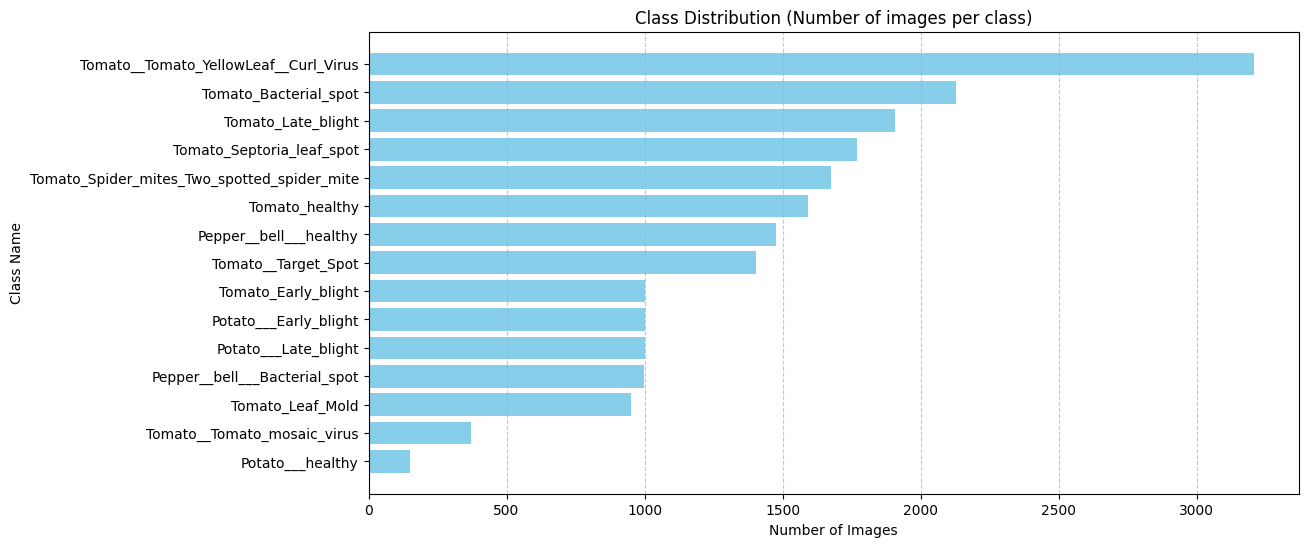

In [15]:
data = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data.append({'Class': class_name, 'Count': count})

df_dist = pd.DataFrame(data).sort_values(by='Count', ascending=False)

print("Image distribution across classes:")
print(df_dist.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(df_dist['Class'], df_dist['Count'], color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.title('Class Distribution (Number of images per class)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Classes Number: 15


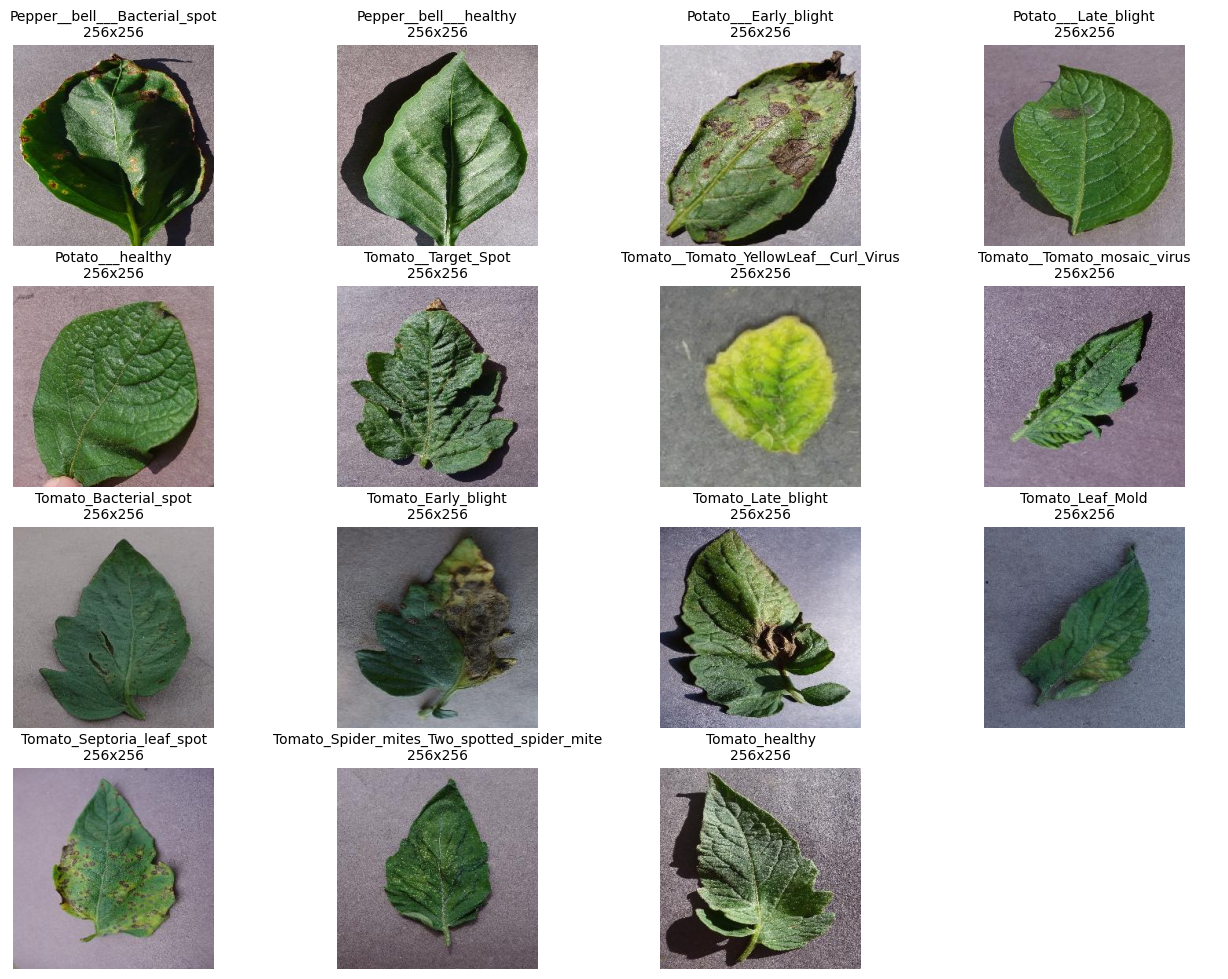

In [16]:
def VisualizeClasses(folders_path):
    # Get all class folders and sort them
    ClassesNames = os.listdir(folders_path)
    ClassesNames.sort(key=lambda x: (x.split('__')[0], x))

    # Display the total number of classes
    NUM_CLASSES = len(ClassesNames)
    print(f"Classes Number: {NUM_CLASSES}")

    cols = 4
    rows = (NUM_CLASSES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()

    # Show one sample image from each class
    for i, cat in enumerate(ClassesNames):
        ClassFolderPath = os.path.join(folders_path,cat)
        ImagesName = os.listdir(ClassFolderPath)
        img_path = os.path.join(ClassFolderPath,ImagesName[0])
        with Image.open(img_path) as img:
            width, height = img.size
        image = mpimg.imread(img_path)
        axes[i].imshow(image)
        axes[i].set_title(f"{cat}\n{width}x{height}", fontsize=10)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

VisualizeClasses(IMAGES_FOLDERS_PATH)

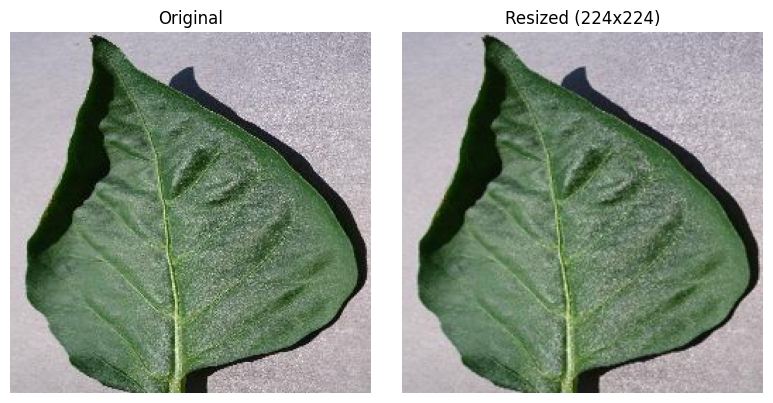

In [17]:
# Pick a random class folder
ClassesNames = os.listdir(IMAGES_FOLDERS_PATH)
random_class = random.choice(ClassesNames)
class_path = os.path.join(IMAGES_FOLDERS_PATH, random_class)

# Pick a random image from that class
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

# Open and resize the selected image to 224x224
with Image.open(img_path) as img:
    resized_img = img.resize((WIDTH, HEIGHT))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized ({WIDTH}x{HEIGHT})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

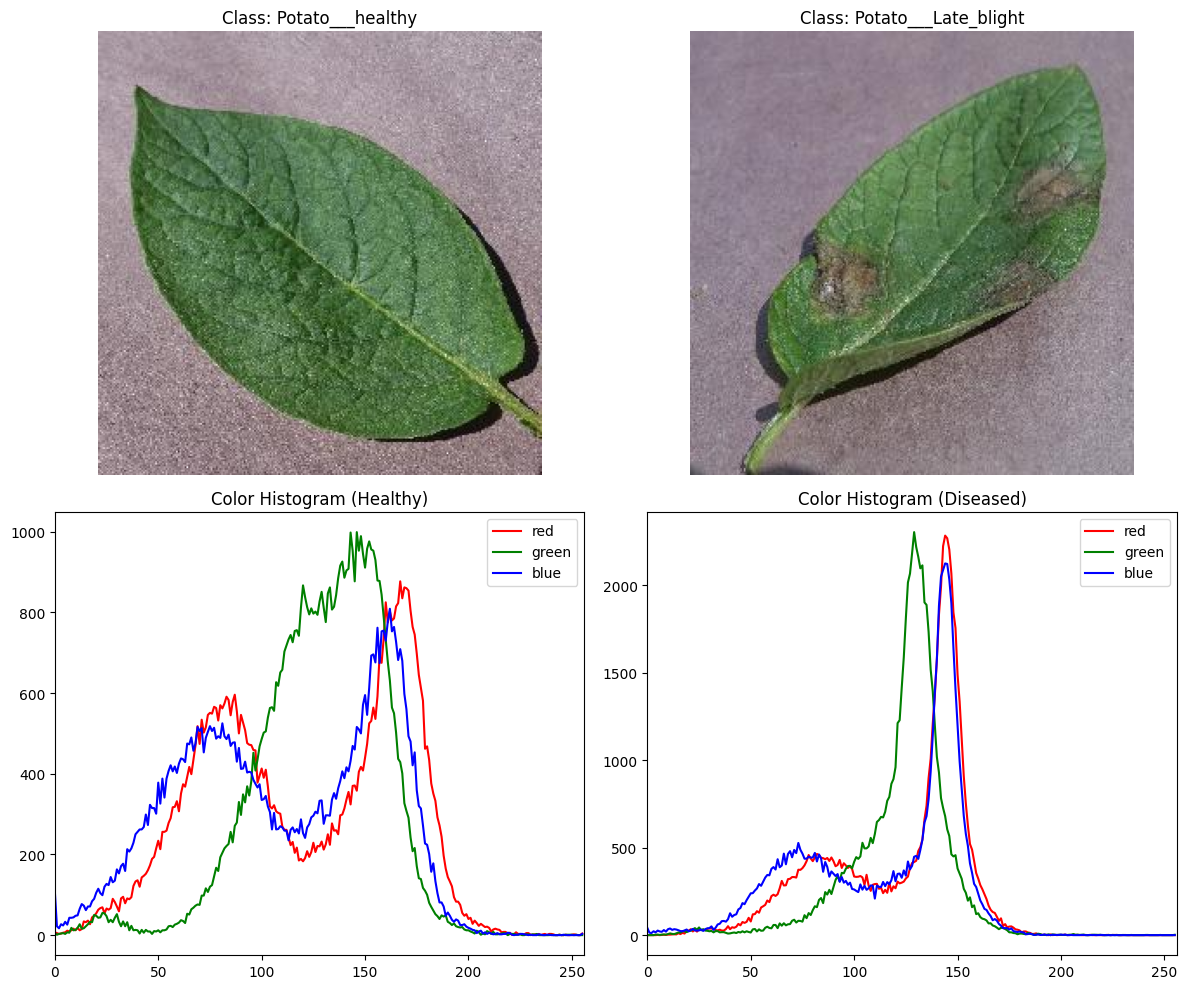

In [18]:
def plot_healthy_vs_diseased(plant_name):
    all_classes = [d for d in os.listdir(IMAGES_FOLDERS_PATH) if d.startswith(plant_name)]

    healthy_class = [c for c in all_classes if 'healthy' in c.lower()]
    diseased_classes = [c for c in all_classes if 'healthy' not in c.lower()]

    if not healthy_class or not diseased_classes:
        print(f"Couldn't find both healthy and diseased for {plant_name}")
        return

    target_diseased = random.choice(diseased_classes)
    target_healthy = healthy_class[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for i, class_name in enumerate([target_healthy, target_diseased]):
        class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Class: {class_name}")
        axes[0, i].axis('off')

        colors = ('red', 'green', 'blue')
        for j, col in enumerate(colors):
            hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
            axes[1, i].plot(hist, color=col, label=col)
            axes[1, i].set_xlim([0, 256])

        axes[1, i].set_title(f"Color Histogram ({'Healthy' if i==0 else 'Diseased'})")
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

plot_healthy_vs_diseased('Potato')

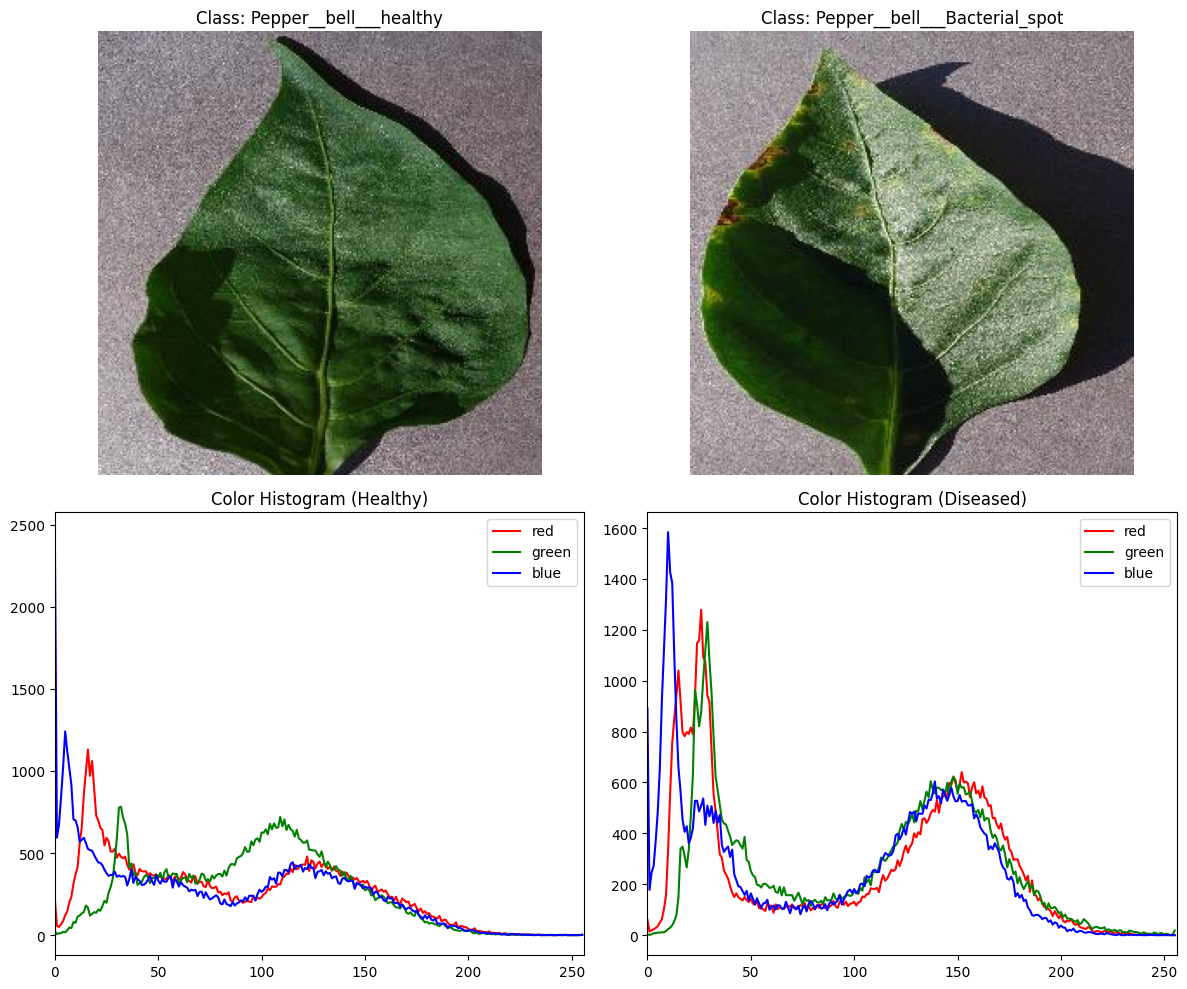

In [19]:
plot_healthy_vs_diseased('Pepper')

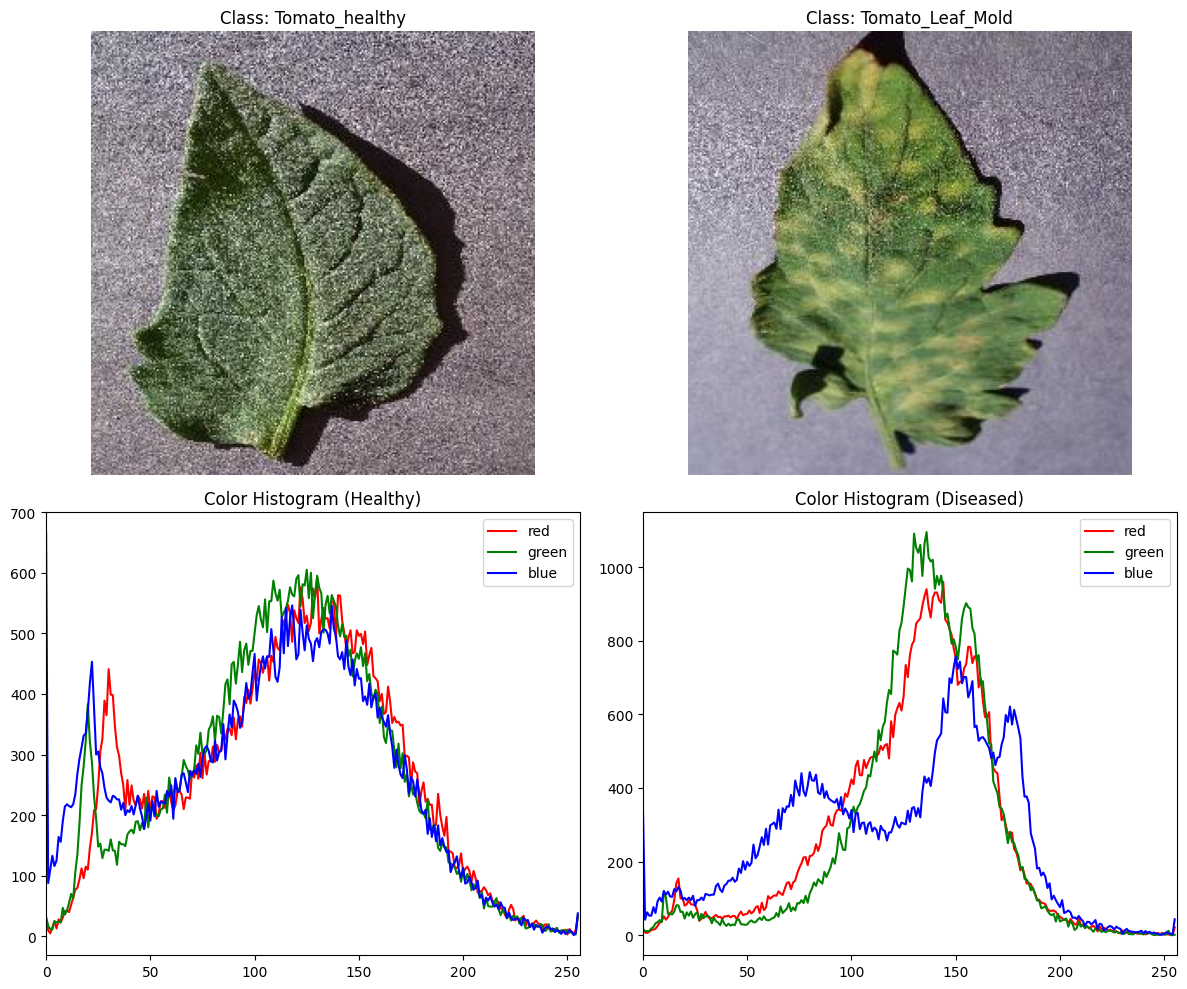

In [20]:
plot_healthy_vs_diseased('Tomato')

## 5. Data Split (70% train / 15% val / 15% test)

In [21]:
splitfolders.ratio(
    IMAGES_FOLDERS_PATH,
    output=OUTPUT_FOLDER,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

train_path = os.path.join(OUTPUT_FOLDER, "train")
val_path   = os.path.join(OUTPUT_FOLDER, "val")
test_path  = os.path.join(OUTPUT_FOLDER, "test")

print(f"Train : {train_path}")
print(f"Val   : {val_path}")
print(f"Test  : {test_path}")

Copying files: 20639 files [02:16, 150.76 files/s]

Train : /kaggle/working/plantdisease_split/train
Val   : /kaggle/working/plantdisease_split/val
Test  : /kaggle/working/plantdisease_split/test


## 6. Feature Extraction (Color Histogram + LBP + GLCM)

In [22]:
def compute_color_histogram(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hist_features = []
    for i in range(3):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)
    return hist_features

def compute_texture_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (WIDTH, HEIGHT))

    lbp = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, LBP_METHOD)
    n_bins = LBP_N_POINTS + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                                range=(0, n_bins), density=True)

    gray_small = (gray // 4).astype(np.uint8)
    levels = 64
    glcm   = np.zeros((levels, levels), dtype=np.float64)
    glcm[gray_small[:, :-1].ravel(),
         gray_small[:, 1: ].ravel()] += 1
    glcm += glcm.T
    glcm /= glcm.sum()

    i, j  = np.mgrid[0:levels, 0:levels]
    mu    = (i * glcm).sum()
    denom = np.sqrt((glcm * (i - mu)**2).sum()) * \
            np.sqrt((glcm * (j - mu)**2).sum())

    contrast    = (glcm * (i - j)**2).sum()
    energy      = (glcm**2).sum()
    homogeneity = (glcm / (1.0 + (i - j)**2)).sum()
    correlation = (glcm * (i - mu) * (j - mu)).sum() / (denom + 1e-10)

    return list(lbp_hist) + [contrast, energy, homogeneity, correlation]

In [23]:
all_images = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        all_images.append((class_name, os.path.join(class_path, img_name)))

print(f"Total images: {len(all_images)}")

Total images: 20639


In [24]:
data = []

for class_name, img_path in tqdm(all_images, desc="Extracting features"):
    color_features   = compute_color_histogram(img_path)
    texture_features = compute_texture_features(img_path)

    if color_features is None or texture_features is None:
        continue

    final_features = color_features + texture_features
    data.append({'class': class_name, 'features': final_features})

df = pd.DataFrame(data)
df.to_pickle('/kaggle/working/features.pkl')

print(f"Number of Images: {len(df)}")
print(df.head())

Extracting features: 100%|██████████| 20639/20639 [10:18<00:00, 33.39it/s]


Number of Images: 20638
                           class  \
0  Pepper__bell___Bacterial_spot   
1  Pepper__bell___Bacterial_spot   
2  Pepper__bell___Bacterial_spot   
3  Pepper__bell___Bacterial_spot   
4  Pepper__bell___Bacterial_spot   

                                            features  
0  [0.02583752, 0.0077031115, 0.005937815, 0.0083...  
1  [0.006403104, 0.0018294583, 0.0024392777, 0.00...  
2  [0.0007926307, 0.0003170523, 0.00047557845, 0....  
3  [0.00086839765, 0.0007236647, 0.00043419882, 0...  
4  [0.00019173733, 0.0015338986, 0.0007669493, 0....  


In [25]:
df = pd.read_pickle('/kaggle/working/features.pkl')
X = np.stack(df['features'].values)
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=40, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}\n")

Original number of features: 798
Number of features after PCA: 40



## 7. KNN / Naive Bayes

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
knn_preds = knn.predict(X_test_pca)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")


nb = GaussianNB()
nb.fit(X_train_pca, y_train)
nb_preds = nb.predict(X_test_pca)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds) * 100:.2f}%")

KNN Accuracy: 81.52%
Naive Bayes Accuracy: 53.56%


## 9. CNN (PyTorch)

In [27]:
TRAIN_DATA_PATH = train_path
VAL_DATA_PATH   = val_path

print (f"Training data path: {TRAIN_DATA_PATH}")
print (f"Validation data path: {VAL_DATA_PATH}")

Training data path: /kaggle/working/plantdisease_split/train
Validation data path: /kaggle/working/plantdisease_split/val


In [28]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

TRAIN_DATA_TRANSFORMER = transforms.Compose([
    transforms.Resize((WIDTH, HEIGHT)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

TEST_DATA_TRANSFORMER = transforms.Compose([
    transforms.Resize((WIDTH, HEIGHT)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

In [29]:
train_dataset = ImageFolder(root=TRAIN_DATA_PATH, transform=TRAIN_DATA_TRANSFORMER)
val_dataset = ImageFolder(root=VAL_DATA_PATH, transform=TEST_DATA_TRANSFORMER)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

Number of training samples: 14440
Number of validation samples: 3089


In [30]:
class_names = train_dataset.classes
print(f"Class names: {class_names}")

Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [31]:
class_to_idx = train_dataset.class_to_idx
print(f"Class to index mapping: {class_to_idx}")

Class to index mapping: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [32]:
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count() if os.cpu_count() is not None else 4

TRAIN_DATA_LOADER = DataLoader(
    train_dataset,
    batch_size= BATCH_SIZE,
    shuffle=True,
    num_workers = NUM_WORKERS,
    pin_memory=True
)

TEST_DATA_LOADER = DataLoader(
    val_dataset,
    batch_size= BATCH_SIZE,
    shuffle=False,
    num_workers = NUM_WORKERS,
    pin_memory=True
)

print(f"{len(TRAIN_DATA_LOADER)} Batches in train dataloader")
print(f"{len(TEST_DATA_LOADER)} Batches in test dataloader")

226 Batches in train dataloader
49 Batches in test dataloader


In [33]:
img,label = next(iter(TRAIN_DATA_LOADER))
img,label

(tensor([[[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [ 0.6392,  0.5193,  0.4166,  ...,  0.4508,  0.4679,  0.4508],
           [ 0.3309,  0.6049,  0.6734,  ...,  0.3652,  0.4166,  0.5193],
           ...,
           [-0.0287, -0.0287, -0.1143,  ..., -0.1999, -0.1828, -0.1143],
           [-0.1657, -0.1486, -0.1999,  ..., -0.1143, -0.1828, -0.3198],
           [-0.0287, -0.0458, -0.1314,  ..., -0.0287, -0.0629, -0.3027]],
 
          [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [ 0.7654,  0.6429,  0.5378,  ...,  0.5028,  0.5203,  0.5028],
           [ 0.4503,  0.7304,  0.8004,  ...,  0.4153,  0.4678,  0.5728],
           ...,
           [-0.0049, -0.0049, -0.0924,  ..., -0.1625, -0.1450, -0.0749],
           [-0.1450, -0.1275, -0.1800,  ..., -0.0749, -0.1450, -0.2850],
           [-0.0049, -0.0224, -0.1099,  ...,  0.0126, -0.0224, -0.2675]],
 
          [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
           [ 

In [34]:
img.shape

torch.Size([64, 3, 224, 224])

In [35]:
# Implement the CNN model
class VGG_CNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()

        # Block 1: Input (3, 224, 224) -> Output (32, 112, 112)
        self.cnn_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: Input (32, 112, 112) -> Output (64, 56, 56)
        self.cnn_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: Input (64, 56, 56) -> Output (128, 28, 28)
        self.cnn_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 4: Input (128, 28, 28) -> Output (256, 14, 14)
        self.cnn_block_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.neural_network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(14 * 14 * 256, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.cnn_block_1(x)
        x = self.cnn_block_2(x)
        x = self.cnn_block_3(x)
        x = self.cnn_block_4(x)
        x = self.neural_network(x)
        return x

base_model = VGG_CNN()

In [36]:
summary(base_model,input_size=[1,3,224,224])

Layer (type:depth-idx)                   Output Shape              Param #
VGG_CNN                                  [1, 15]                   --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 64, 112, 112]         18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         128
│    └─ReLU: 2-7                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-8                    [1, 64, 56, 56]           --
├─Sequential: 1-3                        [1, 128, 28, 28]          --
│    └─Conv2d: 2-9                       [1, 128, 56, 56]          73,856
│    

In [37]:
loss_fn = nn.CrossEntropyLoss()
acc_fn = Accuracy(task="multiclass", num_classes=len(class_names)).to(device)
optimizer = torch.optim.Adam(params=base_model.parameters(),lr=0.001,weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer,
                              mode='min',
                              factor=0.1,
                              patience=3,
                              )

In [38]:
# Create train & test step functions
def train_step(
    model: nn.Module,
    dataloader: torch.utils.data,
    loss_fn: nn.Module,
    acc_fn,
    optimizer: torch.optim,
    device=device
):
  model.train()
  total_loss, total_acc = 0,0
  for batch,(X,y) in enumerate(dataloader):
    X = X.to(device)
    y = y.to(device)
    y_logits = model(X)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
    loss = loss_fn(y_logits,y)
    acc = acc_fn(y_pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    total_acc += acc.item()
  total_loss /= len(dataloader)
  total_acc /= len(dataloader)
  return total_loss,total_acc


def test_step(
    model: nn.Module,
    dataloader: torch.utils.data,
    loss_fn: nn.Module,
    acc_fn,
    device=device
):
  model.eval()
  total_loss, total_acc = 0,0
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X = X.to(device)
      y = y.to(device)
      y_logits = model(X)
      y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
      total_loss += loss_fn(y_logits,y).item()
      total_acc += acc_fn(y_pred,y).item()
    total_loss /= len(dataloader)
    total_acc /= len(dataloader)
  return total_loss,total_acc

In [39]:
# Create main train loop for epochs
SAVE_FROM_SCRATCH_MODEL_PATH = f"/kaggle/working/model_from_scratch.pth"
def train(model: nn.Module,
          train_dataloader: torch.utils.data,
          test_dataloader: torch.utils .data,
          loss_fn: nn.Module,
          acc_fn,
          optimizer: torch.optim,
          epochs: int,
          patience: int = 5,
          seed=42,
          ):
  torch.random.manual_seed(seed)
  results = {
      'Train Loss': [],
      'Train Accuracy': [],
      'Test Loss': [],
      'Test Accuracy': []
  }
  best_loss = float('inf')
  patience_counter = 0
  for epoch in tqdm_auto(range(epochs)):
    train_loss,train_acc = train_step(model,train_dataloader,loss_fn,acc_fn,optimizer)
    test_loss,test_acc = test_step(model,test_dataloader,loss_fn,acc_fn)
    scheduler.step(test_loss)
    if test_loss < best_loss:
        best_loss = test_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_FROM_SCRATCH_MODEL_PATH)
    else:
        patience_counter += 1
    print(f"Epoch {epoch+1}/{epochs} - accuracy: {train_acc*100:.2f}% - loss: {train_loss:.4f} - val_accuracy: {test_acc*100:.2f}% - val_loss: {test_loss:.4f}")
    results["Train Loss"].append(train_loss),results["Train Accuracy"].append(train_acc),results["Test Loss"].append(test_loss),results["Test Accuracy"].append(test_acc)
    if patience_counter >= patience:
            print(f"--- Early stopping triggered at epoch {epoch+1} ---")
            break
  model.load_state_dict(torch.load(SAVE_FROM_SCRATCH_MODEL_PATH, weights_only=True))
  return results

In [40]:
base_model = base_model.to(device)
base_model_results = train(base_model,TRAIN_DATA_LOADER,TEST_DATA_LOADER,loss_fn,acc_fn,optimizer,30)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30 - accuracy: 39.74% - loss: 3.1220 - val_accuracy: 62.60% - val_loss: 1.1401
Epoch 2/30 - accuracy: 60.71% - loss: 1.2317 - val_accuracy: 77.37% - val_loss: 0.7046
Epoch 3/30 - accuracy: 69.14% - loss: 0.9634 - val_accuracy: 80.84% - val_loss: 0.5716
Epoch 4/30 - accuracy: 74.22% - loss: 0.7863 - val_accuracy: 77.26% - val_loss: 0.6987
Epoch 5/30 - accuracy: 77.57% - loss: 0.6845 - val_accuracy: 81.09% - val_loss: 0.5418
Epoch 6/30 - accuracy: 79.41% - loss: 0.6248 - val_accuracy: 85.46% - val_loss: 0.4087
Epoch 7/30 - accuracy: 81.36% - loss: 0.5653 - val_accuracy: 89.61% - val_loss: 0.3266
Epoch 8/30 - accuracy: 81.96% - loss: 0.5463 - val_accuracy: 89.42% - val_loss: 0.3077
Epoch 9/30 - accuracy: 83.05% - loss: 0.5038 - val_accuracy: 89.45% - val_loss: 0.3178
Epoch 10/30 - accuracy: 84.12% - loss: 0.4765 - val_accuracy: 90.89% - val_loss: 0.2848
Epoch 11/30 - accuracy: 84.58% - loss: 0.4613 - val_accuracy: 92.03% - val_loss: 0.2400
Epoch 12/30 - accuracy: 86.22% - loss: 0.

In [41]:
def get_predections(model: nn.Module, dataloader: torch.utils.data, device=device):
  model_prediction = []
  model.eval()
  with torch.inference_mode():
    for batch,(X,y) in tqdm_auto(enumerate(dataloader)):
      X = X.to(device)
      y = y.to(device)
      y_logits = model(X)
      y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)
      model_prediction.append(y_preds)
  return torch.cat(model_prediction)

model0_predictions = get_predections(base_model,TEST_DATA_LOADER)
model0_predictions

0it [00:00, ?it/s]

tensor([ 0,  0,  0,  ..., 14, 14, 14], device='cuda:0')

In [42]:
base_model_results_table = pd.DataFrame(base_model_results)
base_model_results_table

,Train Loss,Train Accuracy,Test Loss,Test Accuracy
0,3.121971,0.397428,1.140113,0.626032
1,1.231711,0.607093,0.704591,0.773747
2,0.963399,0.691427,0.571640,0.808355
3,0.786329,0.742174,0.698722,0.772640
4,0.684499,0.775678,0.541841,0.810906
5,0.624801,0.794096,0.408747,0.854592
6,0.565295,0.813579,0.326612,0.896121
7,0.546343,0.819566,0.307669,0.894208
8,0.503777,0.830531,0.317754,0.894452
9,0.476502,0.841247,0.284771,0.908876


## 8. Bagging Algorithms

In [43]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [44]:
acc_rf = accuracy_score(y_test,y_pred_rf)
print(f"RandomForest Accuracy: { acc_rf*100:.2f}%")

RandomForest Accuracy: 85.27%


In [45]:
base_classifier = DecisionTreeClassifier()
#bagging
bagging_classifier = BaggingClassifier(base_classifier ,n_estimators=10,random_state=42)
bagging_classifier.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

In [46]:
y_pred = bagging_classifier.predict(X_test)
acc_bagging = accuracy_score(y_test,y_pred)
print(f"Bagging Accuracy:{acc_bagging *100:.2f}%")

Bagging Accuracy:78.78%


## Boosting algorthim(adaboost)

In [47]:
ada = AdaBoostClassifier( estimator=base_classifier,n_estimators=300,learning_rate=0.1 , random_state=42)
ada.fit(X_train ,y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test , y_pred_ada)
print(f"AdaBoost Accuracy: {acc_ada*100:.2f}%")

AdaBoost Accuracy: 65.43%


In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_params = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1,2]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=cv, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_pca, y_train)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best KNN CV Accuracy:", knn_grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best KNN CV Accuracy: 0.8321623258631133


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.80333131 0.81011508 0.80333131 0.81011508 0.8112659  0.81665657
 0.8112659  0.81665657 0.80944882 0.81526348 0.80944882 0.81526348
 0.80514839 0.81084191 0.80514839 0.81084191 0.79945488 0.80575409
 0.79945488 0.80575409 0.79473047 0.80121139 0.79473047 0.80121139
        nan 0.82804361        nan 0.82804361        nan 0.83216233
        nan 0.83216233        nan 0.83076923        nan 0.83076923
        nan 0.82761962        nan 0.82761962        nan 0.82422774
        nan 0.82422774        nan 0.81744397        nan 0.81744397
        nan 0.82804361 0.80333131 0.81011508        nan 0.83216233
 0.8112659  0.81665657        nan 0.83076923 0.80944882 0.81526348
        nan 0.82761962 0.80514839 0.81084191        nan 0.82422774
 0.79945488 0.80575409        nan 0.81744397 0.79473047 0.80121139]
  warnings.warn(


In [49]:
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'criterion': ['entropy']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced',oob_score=True),
    rf_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_pca, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF CV Accuracy:", rf_grid.best_score_)

Best RF Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV Accuracy: 0.8373107207752877


In [50]:
bagging_params = {
    'n_estimators': [50, 100],
    'max_samples': [0.8, 1.0],
    'max_features': [0.8, 1.0]
}

bagging_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'), random_state=42),
    bagging_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

bagging_grid.fit(X_train_pca, y_train)

print(f"Best Bagging Params: {bagging_grid.best_params_}")
print(f"Best Bagging CV Accuracy: {bagging_grid.best_score_:.4f}")

Best Bagging Params: {'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 100}
Best Bagging CV Accuracy: 0.8264


In [51]:
ada_params = {
    'n_estimators': [50, 150],
    'learning_rate': [0.1, 0.5]
}

base_est = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_est, random_state=42),
    ada_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

ada_grid.fit(X_train_pca, y_train)

print(f"Best AdaBoost Params: {ada_grid.best_params_}")
print(f"Best AdaBoost CV Accuracy: {ada_grid.best_score_:.4f}")

Best AdaBoost Params: {'learning_rate': 0.5, 'n_estimators': 150}
Best AdaBoost CV Accuracy: 0.7455


In [52]:
results = {
    'Model': ['KNN', 'Random Forest', 'Bagging', 'AdaBoost'],
    'Best CV Accuracy': [
        knn_grid.best_score_,
        rf_grid.best_score_,
        bagging_grid.best_score_,
        ada_grid.best_score_
    ]
}
df_results = pd.DataFrame(results).sort_values(by='Best CV Accuracy', ascending=False)

print("--- 1. Models Comparison (Validation Phase) ---")
print(df_results)
print("\n" + "="*50 + "\n")


final_model = rf_grid.best_estimator_
y_pred = final_model.predict(X_test_pca)

print("--- 2. Final Evaluation (Best Model: Random Forest) ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- 1. Models Comparison (Validation Phase) ---
           Model  Best CV Accuracy
1  Random Forest          0.837311
0            KNN          0.832162
2        Bagging          0.826408
3       AdaBoost          0.745548


--- 2. Final Evaluation (Best Model: Random Forest) ---
Final Test Accuracy: 0.8341

Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.81      0.77      0.79       199
                     Pepper__bell___healthy       0.81      0.83      0.82       296
                      Potato___Early_blight       0.87      0.93      0.90       200
                       Potato___Late_blight       0.78      0.71      0.74       200
                           Potato___healthy       0.85      0.57      0.68        30
                      Tomato_Bacterial_spot       0.84      0.89      0.86       426
                        Tomato_Early_blight       0.79      0.

## 10. AutoEncoders

### load data

In [53]:
autoencoder_data = IMAGES_FOLDERS_PATH
#filter healthy images from dataset
healthy_data = []
#resize the images
img_size = 128

print("Starting to load healthy images...")
for folder in os.listdir(autoencoder_data):
    if 'healthy' in folder.lower():
        folder_path = os.path.join(autoencoder_data, folder)

        for img_name in os.listdir(folder_path):
            try:
                img_path = os.path.join(folder_path, img_name)
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (img_size, img_size))

                healthy_data.append(image)
            except Exception as e:
                pass

print(f"Done! Loaded {len(healthy_data)} healthy images.")

Starting to load healthy images...
Done! Loaded 3221 healthy images.


### Data engineering

In [54]:
healthy_data = np.array(healthy_data, dtype='float32')
#Normalization
healthy_data = healthy_data / 255.0
print(f"Data shape: {healthy_data.shape}")
#split
x_train, x_val = train_test_split(healthy_data, test_size=0.2, random_state=42)
print(f"Training set: {x_train.shape}")
print(f"Validation set: {x_val.shape}")

Data shape: (3221, 128, 128, 3)
Training set: (2576, 128, 128, 3)
Validation set: (645, 128, 128, 3)


### Model Archeticture

In [55]:
input_shape = (128, 128, 3)
autoencoder_model = models.Sequential([
    #encoder
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    #Decoder
    layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same'),

    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])
#autoencoder
autoencoder_model.compile(optimizer='adam', loss='mse')
autoencoder_model.summary()

I0000 00:00:1776953849.255791      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10199 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776953849.261146      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 32)   │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,939 (54.45 KB)

 Trainable params: 13,939 (54.45 KB)

 Non-trainable params: 0 (0.00 B)

### Training phase

In [56]:
epochsNum = 50
batchSize = 32

history = autoencoder_model.fit(x_train, x_train,epochs=epochsNum,batch_size=batchSize,
    validation_data=(x_val, x_val),  shuffle=True
)

Epoch 1/50


I0000 00:00:1776953854.810403    1418 service.cc:152] XLA service 0x7bc14402d200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776953854.810463    1418 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953854.810470    1418 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776953855.269313    1418 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-23 14:17:37.175705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:17:37.452637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:17:37.976658: E external/local_xl

 5/81 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0333

I0000 00:00:1776953860.252175    1418 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0295

2026-04-23 14:17:43.912948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:17:44.049793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0293 - val_loss: 0.0176
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0167 - val_loss: 0.0142
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0130 - val_loss: 0.0095
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0091 - val_loss: 0.0082
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0078 - val_loss: 0.0074
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0071 - val_loss: 0.0067
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0065 - val_loss: 0.0064
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0057 - val_

### Output

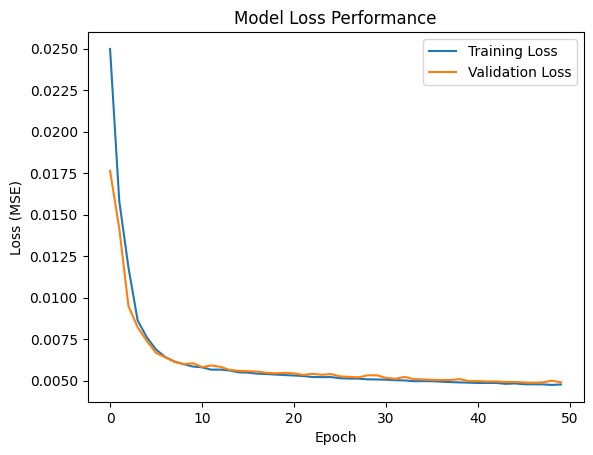

In [57]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Performance')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 11. Transfer Learning — MobileNetV2 & EfficientNetB0

In [58]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)
class_names_tf = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32
)

Found 14440 files belonging to 15 classes.
Found 3089 files belonging to 15 classes.
Found 3109 files belonging to 15 classes.


In [59]:
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

In [60]:
base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_mobilenet.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [61]:
model_mobilenet = tf.keras.Sequential([
    base_mobilenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names_tf), activation='softmax')
])

In [62]:
model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


2026-04-23 14:20:18.038403: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:20:18.175843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


451/452 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6208 - loss: 1.2189

2026-04-23 14:20:42.438282: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:20:42.576958: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:20:42.713668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6211 - loss: 1.2180

2026-04-23 14:21:01.157811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:21:01.295136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


452/452 ━━━━━━━━━━━━━━━━━━━━ 60s 94ms/step - accuracy: 0.6214 - loss: 1.2171 - val_accuracy: 0.8692 - val_loss: 0.4040
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8593 - loss: 0.4402 - val_accuracy: 0.8932 - val_loss: 0.3258
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8799 - loss: 0.3497 - val_accuracy: 0.9009 - val_loss: 0.3024
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9058 - loss: 0.2823 - val_accuracy: 0.8951 - val_loss: 0.3160
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9173 - loss: 0.2468 - val_accuracy: 0.9084 - val_loss: 0.2943
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9201 - loss: 0.2270 - val_accuracy: 0.9162 - val_loss: 0.2505
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9358 - loss: 0.1917 - val_accuracy: 0.9119 - val_loss: 0.2532
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9425 - loss: 0.1679 - val_accurac

In [63]:
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNetB0 has built-in preprocessing.
# train_ds is already normalized to [0,1] via Rescaling(1./255) above,
# so we just prefetch — no second division.
train_ds_e = train_ds.prefetch(AUTOTUNE)
val_ds_e   = val_ds.prefetch(AUTOTUNE)
test_ds_e  = test_ds.prefetch(AUTOTUNE)


In [64]:
base_efficientnet = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_efficientnet.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [65]:
model_efficientnet = tf.keras.Sequential([
    base_efficientnet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names_tf), activation='softmax')
])

In [66]:
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_efficientnet = model_efficientnet.fit(
    train_ds_e,
    validation_data=val_ds_e,
    epochs=10
)

Epoch 1/10


2026-04-23 14:23:44.163496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:23:44.306736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:23:44.664496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:23:44.805683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:23:45.639832: E external/local_xla/xla/stream_

450/452 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1415 - loss: 2.6114

2026-04-23 14:24:14.219469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:14.355816: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:14.669776: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:14.810577: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:15.604143: E external/local_xla/xla/stream_

452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1415 - loss: 2.6113

2026-04-23 14:24:35.726363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:35.866126: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:36.193309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:36.334613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:24:37.147683: E external/local_xla/xla/stream_

452/452 ━━━━━━━━━━━━━━━━━━━━ 72s 106ms/step - accuracy: 0.1415 - loss: 2.6113 - val_accuracy: 0.1557 - val_loss: 2.5696
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1510 - loss: 2.5853 - val_accuracy: 0.1557 - val_loss: 2.5692
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1507 - loss: 2.5831 - val_accuracy: 0.1557 - val_loss: 2.5676
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.1503 - loss: 2.5802 - val_accuracy: 0.1557 - val_loss: 2.5673
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1506 - loss: 2.5771 - val_accuracy: 0.1557 - val_loss: 2.5664
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.1533 - loss: 2.5747 - val_accuracy: 0.1557 - val_loss: 2.5689
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.1546 - loss: 2.5757 - val_accuracy: 0.1557 - val_loss: 2.5666
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.1534 - loss: 2.5746 - val_accura

In [67]:
mobilenet_acc    = model_mobilenet.evaluate(test_ds,   verbose=0)[1]
efficientnet_acc = model_efficientnet.evaluate(test_ds_e, verbose=0)[1]

print("MobileNet Accuracy:", mobilenet_acc)
print("EfficientNet Accuracy:", efficientnet_acc)


2026-04-23 14:27:47.484956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:27:47.634716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:27:47.771256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:27:56.482340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 14:27:56.617226: E external/local_xla/xla/stream_

MobileNet Accuracy: 0.9292377233505249
EfficientNet Accuracy: 0.15503376722335815


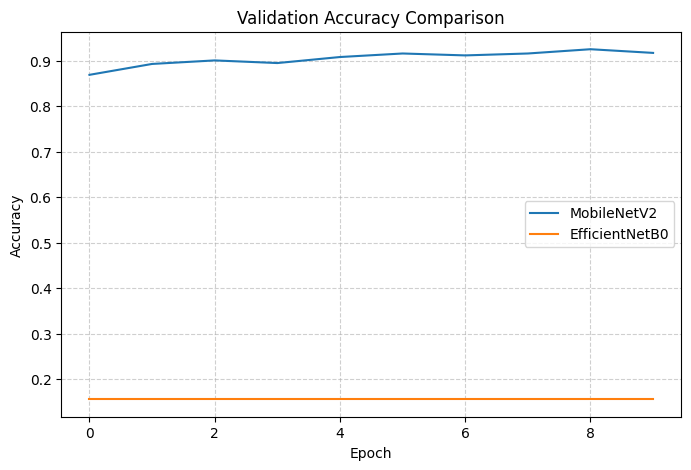

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history['val_accuracy'],    label='MobileNetV2')
plt.plot(history_efficientnet.history['val_accuracy'], label='EfficientNetB0')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## 12. Optimizer Comparison (Adam / SGD / RMSprop)

In [69]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")

In [70]:
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [71]:
def build_model(optimizer, name):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(len(class_names_tf), activation='softmax')
    ], name=name)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [72]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

# ── Adam ──────────────────────────────────────────────────────────────
print("-- Adam --")
# Rebuild augmentation + pipeline after each clear_session()
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

model = build_model(tf.keras.optimizers.Adam(1e-4), "Adam")
history_adam = model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=5, callbacks=[early_stop], verbose=1
)
adam_acc = model.evaluate(test_ds, verbose=0)[1]
del model
tf.keras.backend.clear_session()


# ── SGD ───────────────────────────────────────────────────────────────
print("\n-- SGD --")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

model = build_model(tf.keras.optimizers.SGD(0.01, momentum=0.9), "SGD")
history_sgd = model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=5, callbacks=[early_stop], verbose=1
)
sgd_acc = model.evaluate(test_ds, verbose=0)[1]
del model
tf.keras.backend.clear_session()


# ── RMSprop ───────────────────────────────────────────────────────────
print("\n-- RMSprop --")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation_pipeline")
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

model = build_model(tf.keras.optimizers.RMSprop(1e-4), "RMSprop")
history_rms = model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=5, callbacks=[early_stop], verbose=1
)
rms_acc = model.evaluate(test_ds, verbose=0)[1]
del model
tf.keras.backend.clear_session()


print("\nFinal Results:")
print(f"Adam    : {adam_acc:.4f}")
print(f"SGD     : {sgd_acc:.4f}")
print(f"RMSprop : {rms_acc:.4f}")

best = max(
    {"Adam": adam_acc, "SGD": sgd_acc, "RMSprop": rms_acc},
    key=lambda x: {"Adam": adam_acc, "SGD": sgd_acc, "RMSprop": rms_acc}[x]
)
print(f"\nBest Optimizer: {best}")


-- Adam --
Epoch 1/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 93s 183ms/step - accuracy: 0.3148 - loss: 2.4256 - val_accuracy: 0.7158 - val_loss: 0.9320
Epoch 2/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 156ms/step - accuracy: 0.6720 - loss: 1.0416 - val_accuracy: 0.7782 - val_loss: 0.7021
Epoch 3/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 153ms/step - accuracy: 0.7384 - loss: 0.8045 - val_accuracy: 0.8012 - val_loss: 0.6092
Epoch 4/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 69s 152ms/step - accuracy: 0.7656 - loss: 0.7098 - val_accuracy: 0.8194 - val_loss: 0.5465
Epoch 5/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 69s 152ms/step - accuracy: 0.7899 - loss: 0.6421 - val_accuracy: 0.8323 - val_loss: 0.5136

-- SGD --
Epoch 1/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 90s 178ms/step - accuracy: 0.6248 - loss: 1.2280 - val_accuracy: 0.8249 - val_loss: 0.5209
Epoch 2/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 70s 154ms/step - accuracy: 0.7961 - loss: 0.6196 - val_accuracy: 0.8401 - val_loss: 0.4988
Epoch 3/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - accuracy: 0.

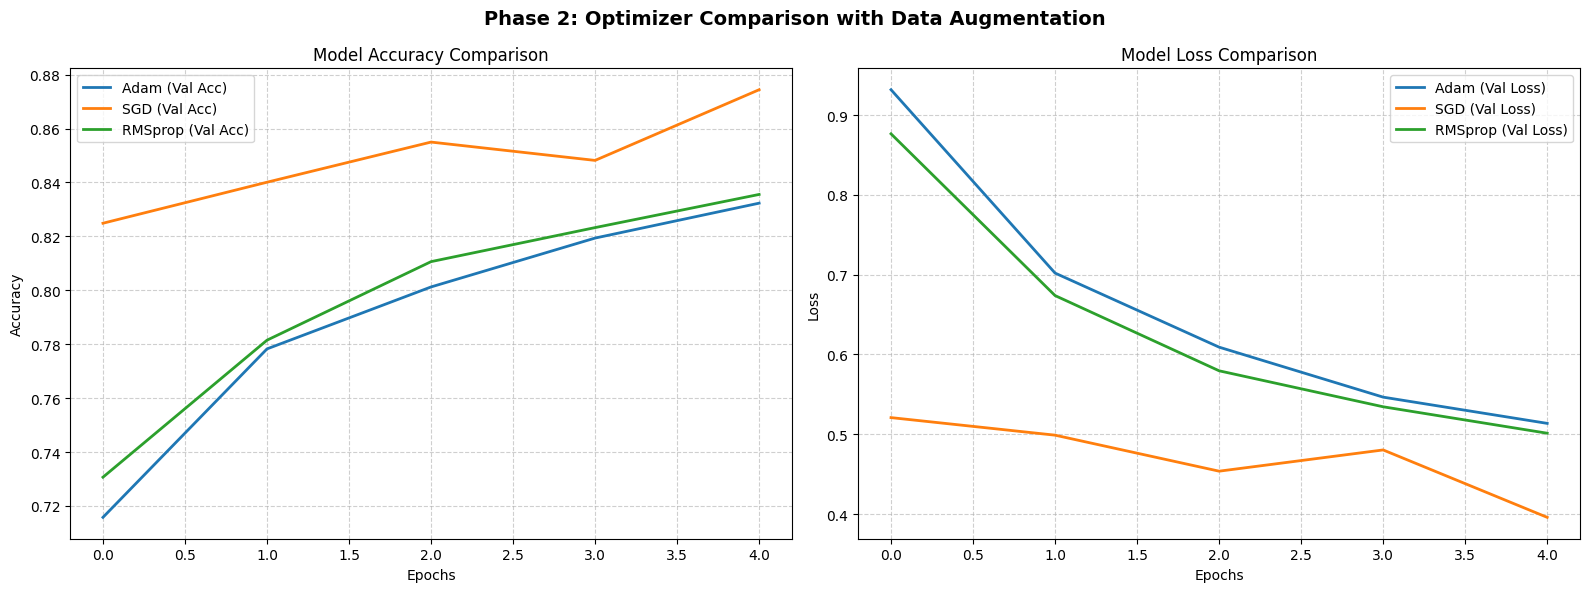

In [73]:
histories = {
    "Adam": history_adam,
    "SGD": history_sgd,
    "RMSprop": history_rms
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Phase 2: Optimizer Comparison with Data Augmentation", fontsize=14, fontweight='bold')

for name, hist in histories.items():
    ax1.plot(hist.history['val_accuracy'], label=f'{name} (Val Acc)', linewidth=2)
    ax2.plot(hist.history['val_loss'], label=f'{name} (Val Loss)', linewidth=2)

ax1.set_title("Model Accuracy Comparison")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.set_title("Model Loss Comparison")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("/kaggle/working/optimizer_performance_curves.png", dpi=150)
plt.show()

In [75]:
print("\n" + "="*40)
print(" SUMMARY: TEST ACCURACY")
print("="*40)
print(f"Adam    : {adam_acc:.4f}")
print(f"SGD     : {sgd_acc:.4f}")
print(f"RMSprop : {rms_acc:.4f}")
print("-" * 40)
print(f"WINNING OPTIMIZER: {best}")
print("="*40)


 SUMMARY: TEST ACCURACY
Adam    : 0.8427
SGD     : 0.8855
RMSprop : 0.8530
----------------------------------------
WINNING OPTIMIZER: SGD


## 13.Confusion Matrix Dashboard

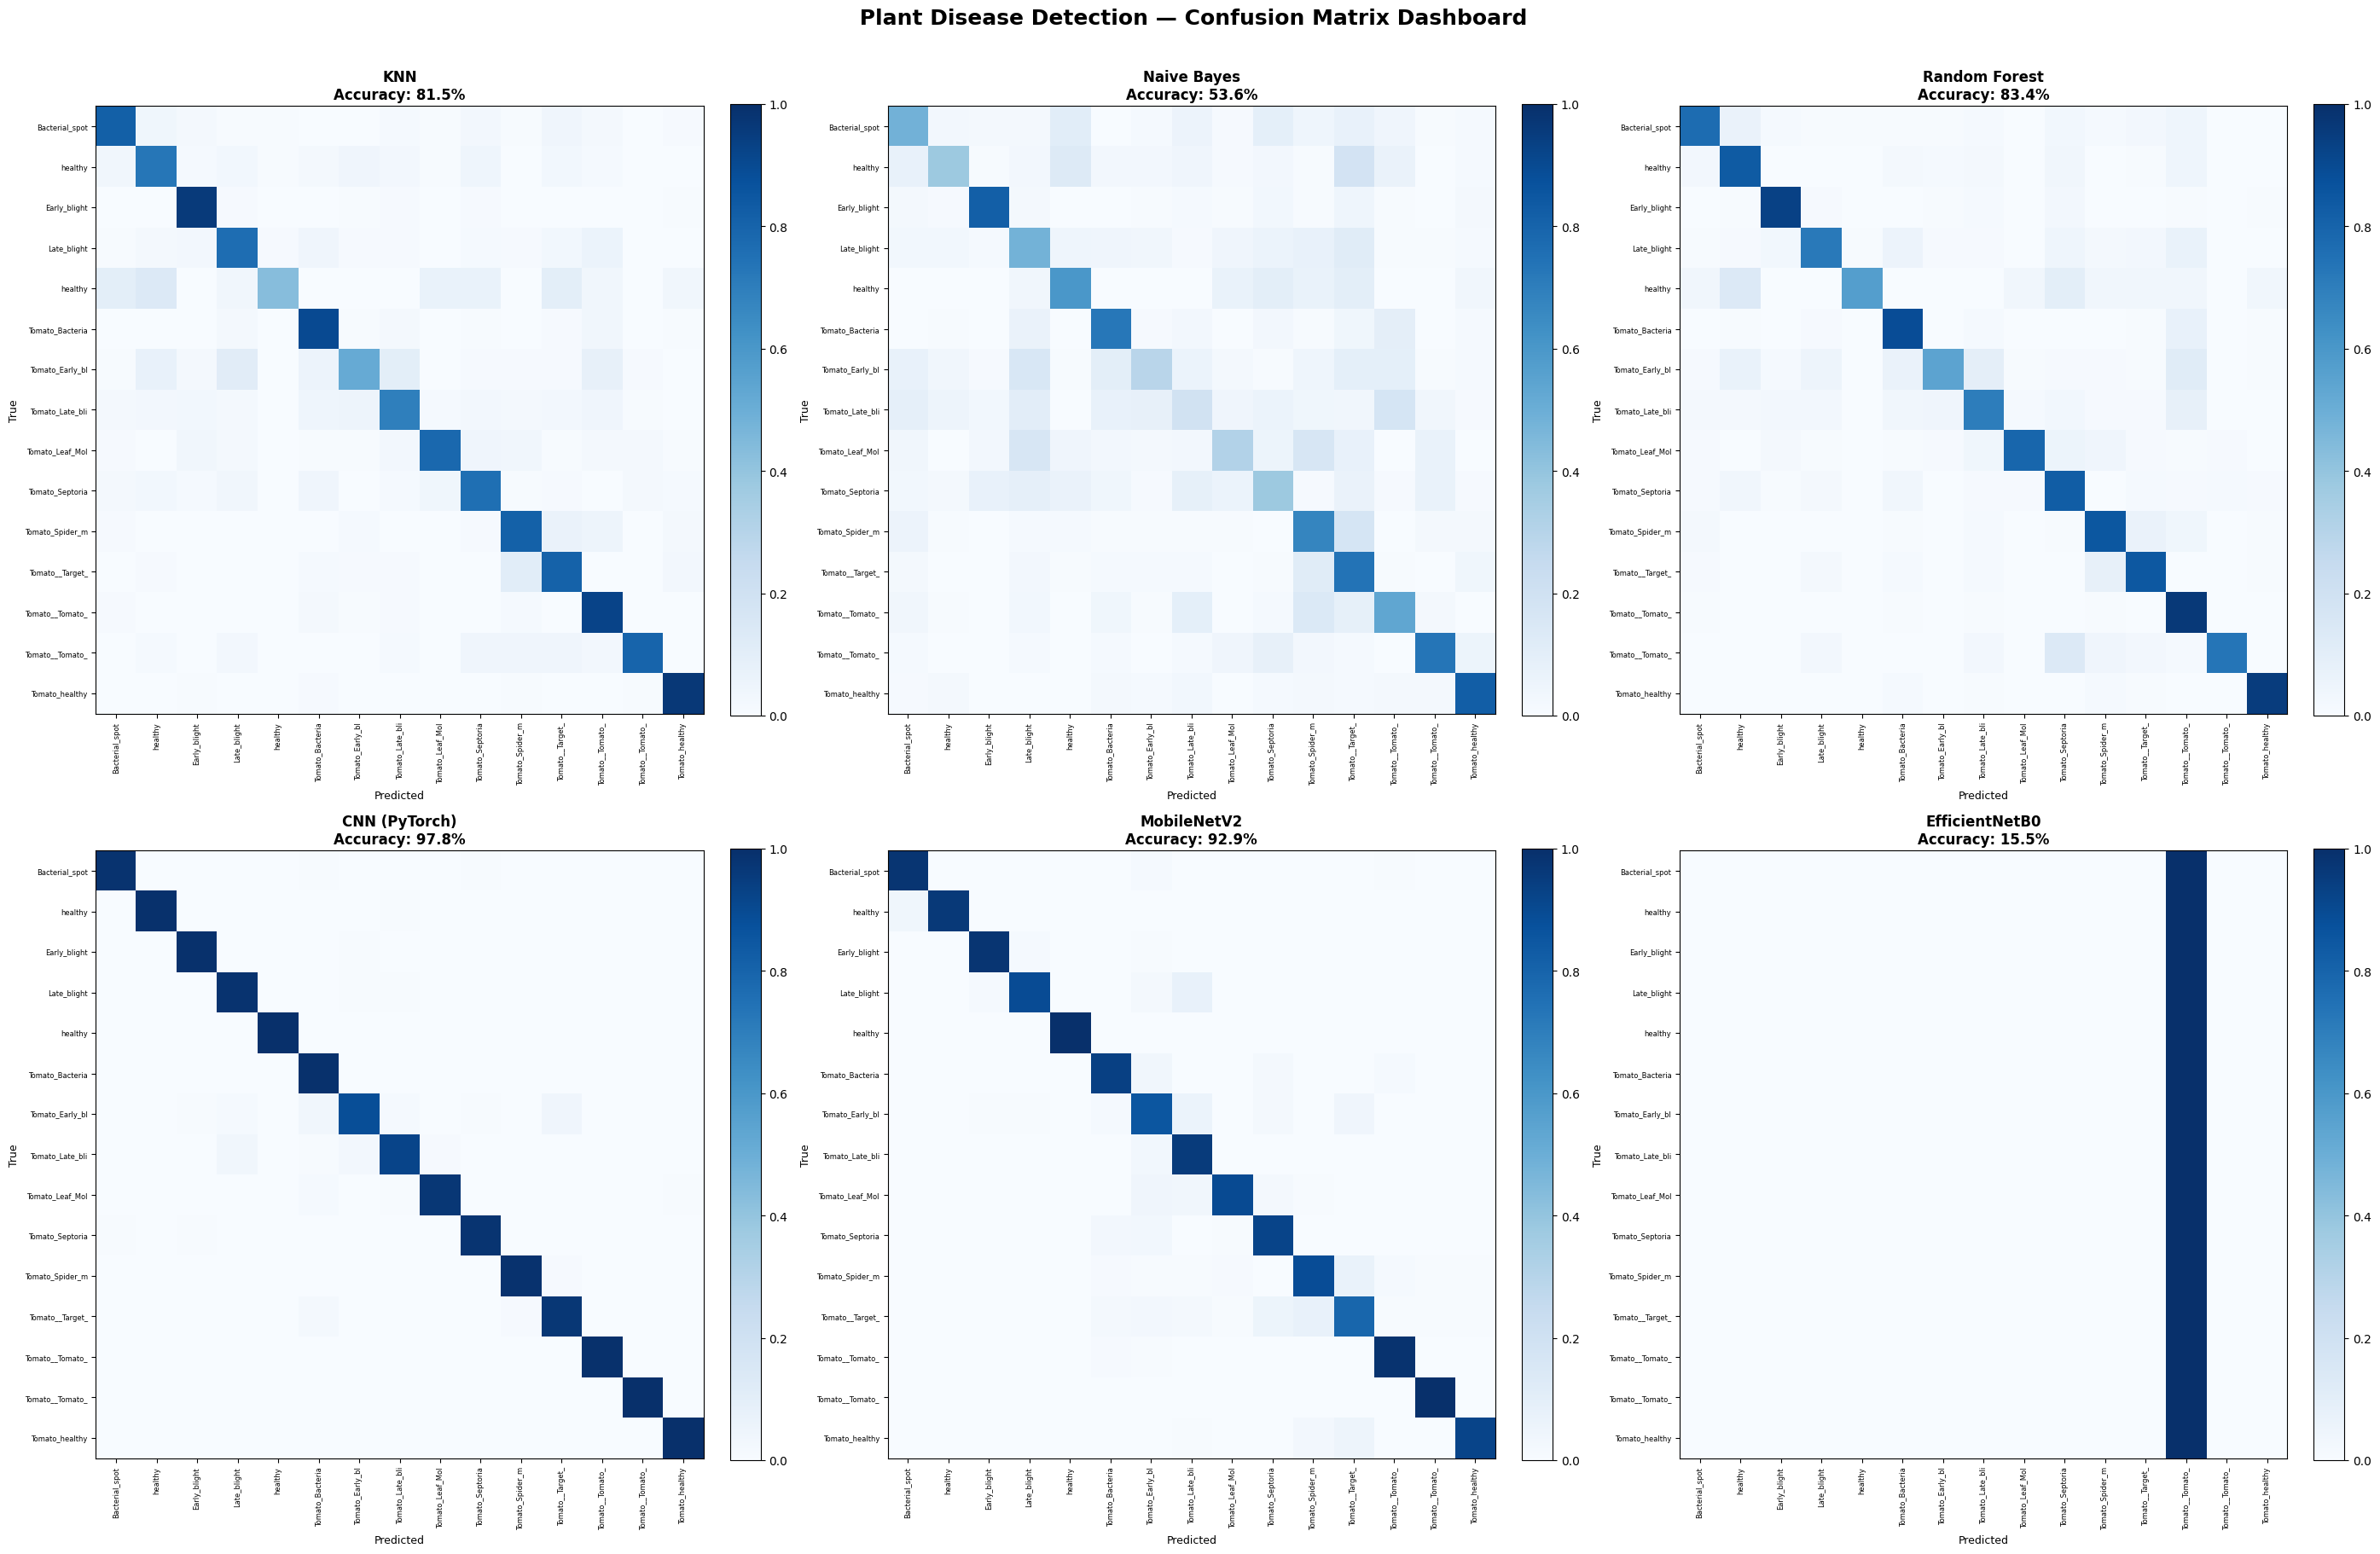

 Saved: /kaggle/working/confusion_matrix_dashboard.png


In [77]:
# ╔══════════════════════════════════════════════════════════════╗
# ║           CONFUSION MATRIX DASHBOARD                        ║
# ╚══════════════════════════════════════════════════════════════╝
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np



# KNN
knn_cm_preds = knn.predict(X_test_pca)

# Naive Bayes
nb_cm_preds = nb.predict(X_test_pca)

# Random Forest (best from GridSearch)
rf_cm_preds = rf_grid.best_estimator_.predict(X_test_pca)


cnn_true_labels = []
for _, labels in TEST_DATA_LOADER:
    cnn_true_labels.extend(labels.numpy())
cnn_true_labels = np.array(cnn_true_labels)
cnn_preds = model0_predictions.cpu().numpy()

# MobileNetV2
mobilenet_preds_list, mobilenet_true_list = [], []
for x_batch, y_batch in test_ds:
    preds = model_mobilenet.predict(x_batch, verbose=0)
    mobilenet_preds_list.extend(np.argmax(preds, axis=1))
    mobilenet_true_list.extend(y_batch.numpy())
mobilenet_preds = np.array(mobilenet_preds_list)
mobilenet_true  = np.array(mobilenet_true_list)

# EfficientNetB0
efficientnet_preds_list, efficientnet_true_list = [], []
for x_batch, y_batch in test_ds_e:
    preds = model_efficientnet.predict(x_batch, verbose=0)
    efficientnet_preds_list.extend(np.argmax(preds, axis=1))
    efficientnet_true_list.extend(y_batch.numpy())
efficientnet_preds = np.array(efficientnet_preds_list)
efficientnet_true  = np.array(efficientnet_true_list)


models_info = [
    ("KNN",          y_test,          knn_cm_preds,        class_names),
    ("Naive Bayes",  y_test,          nb_cm_preds,         class_names),
    ("Random Forest",y_test,          rf_cm_preds,         class_names),
    ("CNN (PyTorch)",cnn_true_labels, cnn_preds,           class_names),
    ("MobileNetV2",  mobilenet_true,  mobilenet_preds,     class_names_tf),
    ("EfficientNetB0",efficientnet_true, efficientnet_preds, class_names_tf),
]

fig, axes = plt.subplots(2, 3, figsize=(28, 18))
fig.suptitle(" Plant Disease Detection — Confusion Matrix Dashboard", 
             fontsize=18, fontweight='bold', y=1.01)

for ax, (name, y_true, y_pred, labels) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_true, y_pred)
    
    # normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # short label names (remove long prefix)
    short_labels = [l.split('___')[-1][:15] if '___' in l else l[:15] for l in labels]
    
    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(short_labels, rotation=90, fontsize=6)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(short_labels, fontsize=6)
    
    # accuracy on title
    acc = np.diag(cm).sum() / cm.sum()
    ax.set_title(f"{name}\nAccuracy: {acc*100:.1f}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: /kaggle/working/confusion_matrix_dashboard.png")